# Avaliação de Modelos: Random Forest vs Onto-RF

Compara o **Random Forest Scikit-Learn** contra o **Onto-RF** (`ClusterAwareRandomForestClassifier`) em **todos os datasets disponíveis**, utilizando **validação cruzada ShuffleSplit** com 20 folds e `test_size=0.3`.

> O `onto_rf.py` precisa estar no mesmo diretório para ser importado.

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import ShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, roc_curve, auc

# Importa nosso Random Forest baseado em Ontologia
from onto_rf import ClusterAwareRandomForestClassifier

## 1. Configuração Global
Defina aqui os parâmetros de validação cruzada e os datasets a serem avaliados.

In [15]:
# ── Datasets disponíveis ──────────────────────────────────────────────────────
DATASETS = ["BLCA", "BRCA", "LIHC", "PRAD"]

# ── Parâmetros de Validação Cruzada ───────────────────────────────────────────
N_SPLITS   = 20     # número de folds
TEST_SIZE  = 0.3    # proporção dos dados para teste em cada fold
RANDOM_STATE = 42

# ── Parâmetros dos Modelos ────────────────────────────────────────────────────
RF_PARAMS = dict(
    n_estimators=100,
    max_depth=5,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

print(f"Datasets: {DATASETS}")
print(f"ShuffleSplit: {N_SPLITS} folds, test_size={TEST_SIZE}")

Datasets: ['BLCA', 'BRCA', 'LIHC', 'PRAD']
ShuffleSplit: 20 folds, test_size=0.3


## 2. Validação Cruzada — Loop sobre todos os Datasets

Para cada dataset:
1. Carrega os dados de expressão gênica e os clusters de ontologia.
2. Executa **20 folds de ShuffleSplit** avaliando RF padrão e Onto-RF.
3. Reporta métricas agregadas (média ± desvio padrão) de F1 e AUC-ROC.
4. Plota as curvas ROC médias.

In [16]:
# Armazena resultados finais de todos os datasets
all_results = {}

cv = ShuffleSplit(n_splits=N_SPLITS, test_size=TEST_SIZE, random_state=RANDOM_STATE)

for DATASET in DATASETS:
    print(f"\n{'='*60}")
    print(f"  Dataset: {DATASET}")
    print(f"{'='*60}")

    # ── 2.1 Carregamento de Dados ─────────────────────────────────────────────
    mRNA_data    = pd.read_csv(f'data/input/deepkegg/{DATASET}_data/mRNA_data.csv')
    response_data = pd.read_csv(f'data/input/deepkegg/{DATASET}_data/response.csv')

    X_raw = mRNA_data.drop(columns=['Case_ID'])
    y     = response_data['response'].values
    feature_names = list(X_raw.columns)

    print(f"  Shape: {X_raw.shape} | pos={sum(y==1)} neg={sum(y==0)}")

    # ── 2.2 Carregamento dos Clusters (KMeans) ────────────────────────────────
    cluster_path = f'data/output/clusters/genes_clustered_{DATASET}.csv'
    df_clusters  = pd.read_csv(cluster_path)
    cluster_map  = df_clusters[['gene', 'cluster_kmeans']]
    print(f"  Clusters mapeados para {len(cluster_map)} genes")

    # ── 2.3 Validação Cruzada ─────────────────────────────────────────────────
    metrics_rf   = {'f1': [], 'auc': [], 'tpr': [], 'fpr_base': np.linspace(0, 1, 100)}
    metrics_onto = {'f1': [], 'auc': [], 'tpr': []}

    X_arr = X_raw.values  # numpy array para o ShuffleSplit indexing

    for fold_i, (train_idx, test_idx) in enumerate(cv.split(X_arr, y)):
        X_tr_raw, X_te_raw = X_arr[train_idx], X_arr[test_idx]
        y_tr,     y_te     = y[train_idx],     y[test_idx]

        # Normalização (fit apenas no treino)
        scaler = StandardScaler()
        X_tr   = scaler.fit_transform(X_tr_raw)
        X_te   = scaler.transform(X_te_raw)

        # DataFrames para o ClusterAwareRF
        X_tr_df = pd.DataFrame(X_tr, columns=feature_names)
        X_te_df = pd.DataFrame(X_te, columns=feature_names)

        # ── Random Forest Padrão ──────────────────────────────────────────────
        clf_std = RandomForestClassifier(**RF_PARAMS)
        clf_std.fit(X_tr, y_tr)
        preds_std   = clf_std.predict(X_te)
        proba_std   = clf_std.predict_proba(X_te)[:, 1]
        fpr, tpr, _ = roc_curve(y_te, proba_std)
        metrics_rf['f1'].append(f1_score(y_te, preds_std, zero_division=0))
        metrics_rf['auc'].append(auc(fpr, tpr))
        # Interpola TPR na grade comum de FPR para poder calcular ROC média
        metrics_rf['tpr'].append(np.interp(metrics_rf['fpr_base'], fpr, tpr))

        # ── Onto-RF ───────────────────────────────────────────────────────────
        clf_onto = ClusterAwareRandomForestClassifier(clusters=cluster_map, **RF_PARAMS)
        clf_onto.fit(X_tr_df, y_tr)
        preds_onto   = clf_onto.predict(X_te_df)
        proba_onto   = clf_onto.predict_proba(X_te_df)[:, 1]
        fpr_o, tpr_o, _ = roc_curve(y_te, proba_onto)
        metrics_onto['f1'].append(f1_score(y_te, preds_onto, zero_division=0))
        metrics_onto['auc'].append(auc(fpr_o, tpr_o))
        metrics_onto['tpr'].append(np.interp(metrics_rf['fpr_base'], fpr_o, tpr_o))

        if (fold_i + 1) % 5 == 0:
            print(f"    fold {fold_i+1:2d}/{N_SPLITS} — "
                  f"RF F1={metrics_rf['f1'][-1]:.3f} AUC={metrics_rf['auc'][-1]:.3f} | "
                  f"OntoRF F1={metrics_onto['f1'][-1]:.3f} AUC={metrics_onto['auc'][-1]:.3f}")

    # ── 2.4 Resumo do Dataset ─────────────────────────────────────────────────
    print(f"\n  {'Modelo':<25} {'F1 (média±std)':>18} {'AUC (média±std)':>18}")
    print(f"  {'-'*62}")
    for name, m in [("Random Forest (Sklearn)", metrics_rf),
                    ("Onto-RF",                 metrics_onto)]:
        f1_mu,  f1_std  = np.mean(m['f1']),  np.std(m['f1'])
        auc_mu, auc_std = np.mean(m['auc']), np.std(m['auc'])
        print(f"  {name:<25} {f1_mu:.4f} ± {f1_std:.4f}   {auc_mu:.4f} ± {auc_std:.4f}")

    all_results[DATASET] = {'rf': metrics_rf, 'onto': metrics_onto}

print(f"\n\n{'='*60}")
print("  Validação Cruzada Concluída para todos os datasets!")
print(f"{'='*60}")


  Dataset: BLCA
  Shape: (402, 1000) | pos=143 neg=259
  Clusters mapeados para 997 genes
    fold  5/20 — RF F1=0.344 AUC=0.646 | OntoRF F1=0.316 AUC=0.676
    fold 10/20 — RF F1=0.281 AUC=0.636 | OntoRF F1=0.175 AUC=0.584
    fold 15/20 — RF F1=0.145 AUC=0.613 | OntoRF F1=0.172 AUC=0.641
    fold 20/20 — RF F1=0.258 AUC=0.579 | OntoRF F1=0.230 AUC=0.569

  Modelo                        F1 (média±std)    AUC (média±std)
  --------------------------------------------------------------
  Random Forest (Sklearn)   0.2991 ± 0.0671   0.6415 ± 0.0525
  Onto-RF                   0.2787 ± 0.0751   0.6379 ± 0.0533

  Dataset: BRCA
  Shape: (211, 1000) | pos=82 neg=129
  Clusters mapeados para 996 genes
    fold  5/20 — RF F1=0.359 AUC=0.622 | OntoRF F1=0.410 AUC=0.686
    fold 10/20 — RF F1=0.378 AUC=0.610 | OntoRF F1=0.350 AUC=0.608
    fold 15/20 — RF F1=0.476 AUC=0.691 | OntoRF F1=0.350 AUC=0.677
    fold 20/20 — RF F1=0.390 AUC=0.673 | OntoRF F1=0.229 AUC=0.666

  Modelo                  

## 3. Sumário Comparativo Final
Tabela consolidada com as métricas médias de todos os datasets.

In [17]:
rows = []
for ds, res in all_results.items():
    for model_name, m in [("RF (Sklearn)", res['rf']), ("Onto-RF", res['onto'])]:
        rows.append({
            'Dataset': ds,
            'Modelo': model_name,
            'F1 Média': np.mean(m['f1']),
            'F1 Std':   np.std(m['f1']),
            'AUC Média': np.mean(m['auc']),
            'AUC Std':   np.std(m['auc']),
        })

df_summary = pd.DataFrame(rows)
df_summary = df_summary.set_index(['Dataset', 'Modelo'])
df_summary = df_summary.round(4)
display(df_summary)

F1 Média  F1 Std  AUC Média  AUC Std
Dataset Modelo                                            
BLCA    RF (Sklearn)    0.2991  0.0671     0.6415   0.0525
        Onto-RF         0.2787  0.0751     0.6379   0.0533
BRCA    RF (Sklearn)    0.3611  0.0890     0.6616   0.0546
        Onto-RF         0.3179  0.0882     0.6638   0.0386
LIHC    RF (Sklearn)    0.5388  0.0616     0.6037   0.0491
        Onto-RF         0.5351  0.0574     0.5935   0.0541
PRAD    RF (Sklearn)    0.5644  0.0608     0.7472   0.0463
        Onto-RF         0.5797  0.0648     0.7497   0.0413

## 4. Curvas ROC Médias por Dataset
Curva ROC média (± desvio padrão da TPR) calculada sobre os 20 folds de ShuffleSplit para cada dataset.

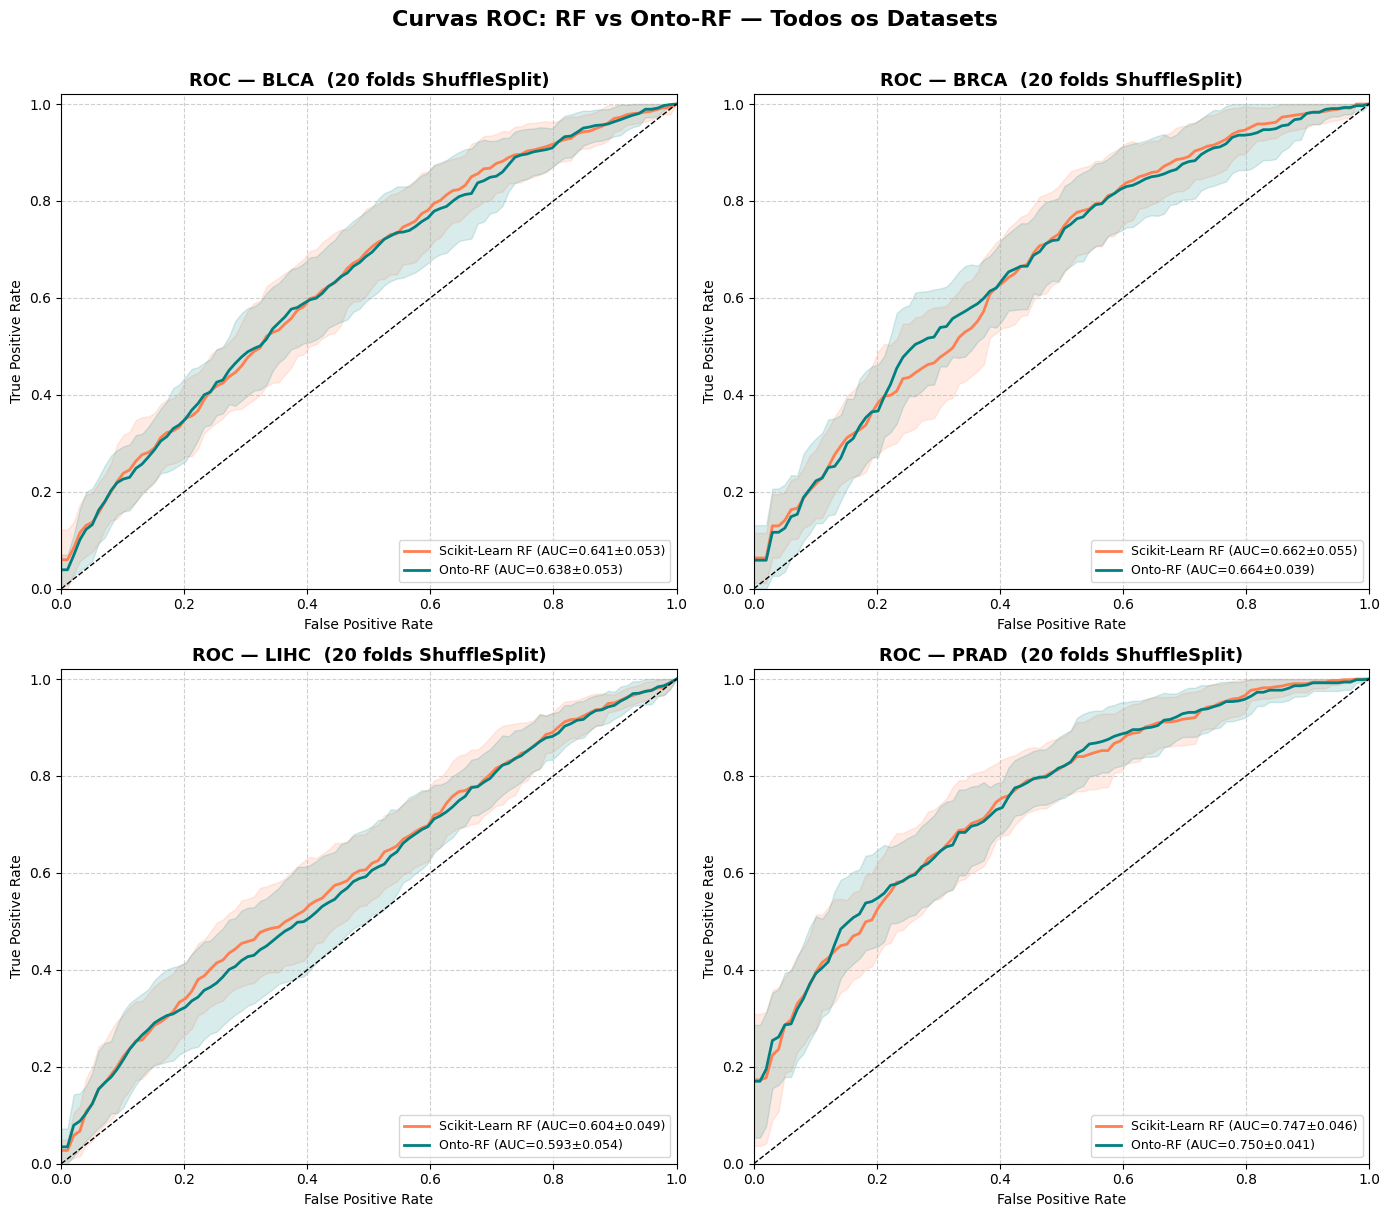

In [18]:
n_datasets = len(all_results)
ncols = 2
nrows = (n_datasets + 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(14, 6 * nrows))
axes = axes.flatten()

for ax_i, (ds, res) in enumerate(all_results.items()):
    ax = axes[ax_i]
    fpr_base = res['rf']['fpr_base']

    for name, m, color in [
        ("Scikit-Learn RF", res['rf'],   'coral'),
        ("Onto-RF",         res['onto'], 'teal'),
    ]:
        mean_tpr = np.mean(m['tpr'], axis=0)
        std_tpr  = np.std(m['tpr'],  axis=0)
        mean_auc = np.mean(m['auc'])
        std_auc  = np.std(m['auc'])

        ax.plot(fpr_base, mean_tpr, color=color, linewidth=2,
                label=f"{name} (AUC={mean_auc:.3f}±{std_auc:.3f})")
        ax.fill_between(fpr_base,
                        np.clip(mean_tpr - std_tpr, 0, 1),
                        np.clip(mean_tpr + std_tpr, 0, 1),
                        color=color, alpha=0.15)

    ax.plot([0, 1], [0, 1], 'k--', linewidth=1)
    ax.set_title(f"ROC — {ds}  ({N_SPLITS} folds ShuffleSplit)",
                 fontsize=13, fontweight='bold')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.legend(loc='lower right', fontsize=9)
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1.02])

# Remove eixos extras caso n_datasets seja ímpar
for ax_j in range(n_datasets, len(axes)):
    axes[ax_j].set_visible(False)

plt.suptitle('Curvas ROC: RF vs Onto-RF — Todos os Datasets',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()